**Data Exploration**

Load in all raw CSV data from the MLS

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

folder = Path("raw")

csv_files = folder.glob("*.csv")

df = pd.concat(
    [pd.read_csv(file) for file in csv_files],
    ignore_index=True
)

df.head()

/var/folders/mf/9m6y4nlx41z0kjyljz4sn3tc0000gn/T/ipykernel_31726/3780106522.py:11: DtypeWarning: Columns (0: WaterfrontYN, 1: ElementarySchool, 2: BuilderName, 3: CoBuyerAgentFirstName, 4: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(file) for file in csv_files],
/var/folders/mf/9m6y4nlx41z0kjyljz4sn3tc0000gn/T/ipykernel_31726/3780106522.py:11: DtypeWarning: Columns (0: latfilled, 1: lonfilled) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(file) for file in csv_files],
/var/folders/mf/9m6y4nlx41z0kjyljz4sn3tc0000gn/T/ipykernel_31726/3780106522.py:11: DtypeWarning: Columns (0: WaterfrontYN) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(file) for file in csv_files],
/var/folders/mf/9m6y4nlx41z0kjyljz4sn3tc0000gn/T/ipykernel_31726/3780106522.py:11: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on impor

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR
0,NaN,True,NaN,NaN,NaN,159000.0,555125771,deborah.potestio@c21selectgroup.com,2024-04-29,45000.0,...,NaN,NaN,95916,0.0,336283.2,NaN,False,False,NaN,NaN
1,NaN,True,NaN,NaN,NaN,144000.0,554271746,crchapman@sbcglobal.net,2024-04-26,78000.0,...,NaN,NaN,95966,0.0,101495.0,NaN,False,False,NaN,NaN
2,NaN,True,NaN,NaN,False,265000.0,543251400,michaelg@londonproperties.com,2024-04-02,250000.0,...,2.0,Fresno Unified,93726,0.0,8100.0,NaN,False,False,NaN,NaN
3,NaN,True,NaN,NaN,NaN,925000.0,539236677,chris.campbell@msn.com,2024-04-10,815000.0,...,NaN,NaN,92223,0.0,564988.0,NaN,False,False,NaN,NaN
4,NaN,True,NaN,NaN,NaN,25000.0,538449222,rrinder@sbcglobal.net,2024-04-06,15000.0,...,NaN,NaN,95966,0.0,6098.0,NaN,False,False,NaN,NaN


Filter data to only contain PropertyType="Residential" and PropertySubType="SingleFamilyResidence"

In [3]:
filtered_df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].reset_index(drop=True)

Explore Distributions: Summary Statistics

In [6]:
cols = ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]

explore_df = filtered_df[cols].copy()

# Ensure they are numeric
for col in cols:
    explore_df[col] = pd.to_numeric(explore_df[col], errors="coerce")

summary_stats = explore_df.describe().T

summary_stats

,count,mean,std,min,25%,50%,75%,max
ClosePrice,399155.0,1.285092e+06,5.237207e+06,0.0,620000.0,889000.0,1425000.0,9.895000e+08
LivingArea,398947.0,2.036718e+03,3.803275e+03,0.0,1373.0,1800.0,2417.5,2.308680e+06
BedroomsTotal,399157.0,3.476710e+00,9.605173e-01,0.0,3.0,3.0,4.0,4.500000e+01
BathroomsTotalInteger,399082.0,2.610133e+00,1.182700e+00,0.0,2.0,2.0,3.0,1.750000e+02
LotSizeSquareFeet,392331.0,2.454994e+05,1.387443e+07,0.0,5663.0,7247.0,10340.0,2.087221e+09


Explore Distributions: Plots

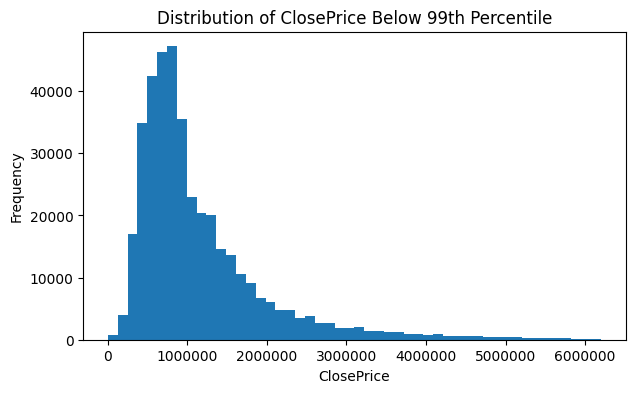

99th percentile cutoff: 6200000.0
Max ClosePrice: 989500000.0


In [ ]:
# Close Price Distribution
close_price = explore_df["ClosePrice"].dropna()

# Remove extreme values for plotting purposes
cutoff = close_price.quantile(0.99)
close_price_trimmed = close_price[close_price <= cutoff]

plt.figure(figsize=(7, 4))
plt.hist(close_price_trimmed, bins=50)
plt.title("Distribution of ClosePrice Below 99th Percentile")
plt.xlabel("ClosePrice")
plt.ylabel("Frequency")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

# Print the cutoff to see what was removed
print("99th percentile cutoff:", cutoff)
print("Max ClosePrice:", close_price.max())

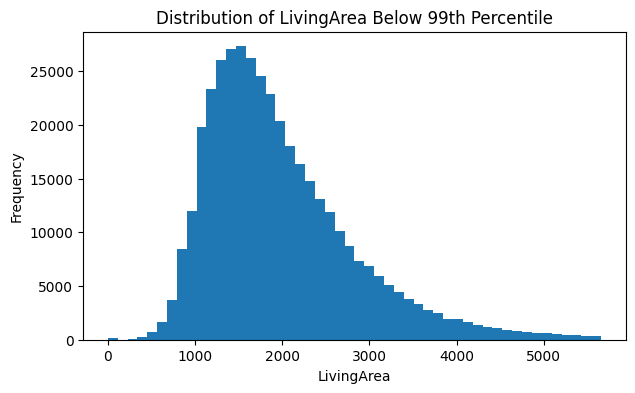

99th percentile cutoff: 5655.0
Max LivingArea: 2308680.0


In [44]:
# Living Area Distribution
living_area = explore_df["LivingArea"].dropna()

# Remove extreme values for plotting purposes
cutoff = living_area.quantile(0.99)
living_area_trimmed = living_area[living_area <= cutoff]

plt.figure(figsize=(7, 4))
plt.hist(living_area_trimmed, bins=50)
plt.title("Distribution of LivingArea Below 99th Percentile")
plt.xlabel("LivingArea")
plt.ylabel("Frequency")
plt.show()

# Print the cutoff to see what was removed
print("99th percentile cutoff:", cutoff)
print("Max LivingArea:", living_area.max())

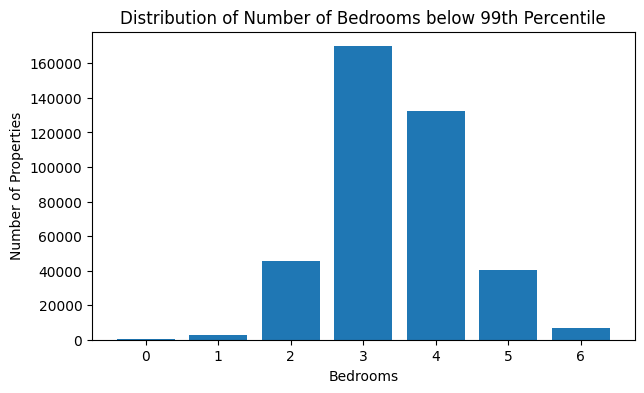

99th percentile cutoff: 6.0
Max Bedrooms: 45.0


In [ ]:
# Bedrooms Distribution as Bar Chart
bedrooms_total = explore_df["BedroomsTotal"].dropna()

# Remove extreme values for plotting purposes
cutoff = bedrooms_total.quantile(0.99)
bedrooms_total_trimmed = bedrooms_total[bedrooms_total <= cutoff]

bedroom_counts = bedrooms_total_trimmed.value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(bedroom_counts.index, bedroom_counts.values)
plt.title("Distribution of Number of Bedrooms below 99th Percentile")
plt.xlabel("Bedrooms")
plt.ylabel("Number of Properties")
plt.xticks(bedroom_counts.index)
plt.show()

print("99th percentile cutoff:", cutoff)
print("Max Bedrooms:", bedrooms_total.max())

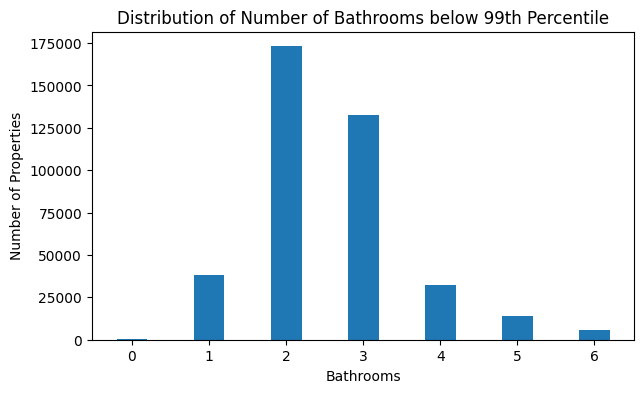

99th percentile cutoff: 6.0
Max Bathrooms: 175.0


In [43]:
# Bathrooms Distribution as Bar Chart
bathrooms = explore_df["BathroomsTotalInteger"].dropna()

# Remove extreme values for plotting purposes
cutoff = bathrooms.quantile(0.99)
bathrooms_trimmed = bathrooms[bathrooms <= cutoff]

bathroom_counts = bathrooms_trimmed.value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(bathroom_counts.index, bathroom_counts.values, width=0.4)
plt.title("Distribution of Number of Bathrooms below 99th Percentile")
plt.xlabel("Bathrooms")
plt.ylabel("Number of Properties")
plt.xticks(bathroom_counts.index)
plt.show()

print("99th percentile cutoff:", cutoff)
print("Max Bathrooms:", bathrooms.max())